# Day 5 — Tuning, Evaluation & Sprint Review

## Data Preparation for Neural Network Tuning

In [1]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv(r"C:\Users\Hp\Desktop\binx_mohammadabuhamed\binx_mohammadabuhamed\Cardiac Patients\data\dataprocessed_heart_data.csv")
X=df.drop('has_heart_disease',axis=1)
y=df['has_heart_disease']
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)
catcols=X.select_dtypes(include='object').columns
numcols=X.select_dtypes(exclude='object').columns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
preprocceser=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numcols),
        ('cat',OneHotEncoder(handle_unknown='ignore'),catcols)
    ]
    
)
X_train_pre=preprocceser.fit_transform(X_train)
X_test_pre=preprocceser.transform(X_test)
n_features = X_train_pre.shape[1]
print("Number of input features:", n_features)

Number of input features: 31


C:\Users\Hp\AppData\Local\Temp\ipykernel_19424\324308732.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catcols=X.select_dtypes(include='object').columns


## Step 1 + 2 — Tune the Neural Network One Hyperparameter at a Time

The Neural Network will be tuned by changing one hyperparameter at a time while keeping the remaining settings fixed.

The validation results from each experiment will be recorded and compared to determine which configuration performs better.

### Build a Reusable Neural Network for Learning Rate Tuning

In [2]:
def build_model(learning_rate):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(n_features,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    optimizer = tf.keras.optimizers.Adam( learning_rate=learning_rate )
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy",tf.keras.metrics.Recall(name="recall") ]
    )
    return model

### Add Early Stopping and Model Checkpoint

In [3]:
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
checkpoint=tf.keras.callbacks.ModelCheckpoint('best_lr_0001.keras',monitor='val_loss',save_best_only=True)

### Learning Rate Experiment 1 — 0.0001

In [4]:
model_lr_0001 = build_model(0.0001)
history_lr_0001 = model_lr_0001.fit(
    X_train_pre,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop,checkpoint]
)

Epoch 1/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5241 - loss: 0.9465 - recall: 0.5519 - val_accuracy: 0.6167 - val_loss: 0.6412 - val_recall: 0.6268
Epoch 2/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6175 - loss: 0.7494 - recall: 0.6361 - val_accuracy: 0.7042 - val_loss: 0.5575 - val_recall: 0.7371
Epoch 3/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6769 - loss: 0.6541 - recall: 0.6963 - val_accuracy: 0.7563 - val_loss: 0.4923 - val_recall: 0.7629
Epoch 4/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7193 - loss: 0.5785 - recall: 0.7089 - val_accuracy: 0.7979 - val_loss: 0.4437 - val_recall: 0.7746
Epoch 5/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7490 - loss: 0.5227 - recall: 0.7158 - val_accuracy: 0.8160 - val_loss: 0.4102 - val_recall: 0.7723
Epoch 6/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7707 - loss: 0.4937 - recall: 0.7381 - val_accuracy: 0.8313 - val_loss: 0.3823 - val_recall: 0.765

### Record Experiment 1 Results

In [5]:
best_val_loss_0001 = min(history_lr_0001.history["val_loss"])
best_val_recall_0001 = max(history_lr_0001.history["val_recall"])
epochs_trained_0001 = len(history_lr_0001.history["loss"])
print("Best Validation Loss:", best_val_loss_0001)
print("Best Validation Recall:", best_val_recall_0001)
print("Epochs Trained:", epochs_trained_0001)

Best Validation Loss: 0.25671496987342834
Best Validation Recall: 0.7746478915214539
Epochs Trained: 66


### Experiment 1 Result

With a Learning Rate of `0.0001`, the model achieved:

- Best Validation Loss: **0.2587**
- Best Validation Recall: **0.7746**
- Epochs Trained: **66**

EarlyStopping stopped the training before reaching 100 epochs because the validation loss stopped improving for the specified patience period.

### Experiment 2 — Learning Rate = 0.001

Create a model

In [6]:
model_lr_001 = build_model(0.001)

new checkpoint for the new model

In [7]:
checkpoint_001 = tf.keras.callbacks.ModelCheckpoint(
    "best_lr_001.keras",
    monitor="val_loss",
    save_best_only=True
)

the training

In [8]:
history_lr_001 = model_lr_001.fit(
    X_train_pre,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint_001]
)

Epoch 1/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7420 - loss: 0.5382 - recall: 0.7438 - val_accuracy: 0.8715 - val_loss: 0.3384 - val_recall: 0.7723
Epoch 2/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8486 - loss: 0.3523 - recall: 0.7524 - val_accuracy: 0.8854 - val_loss: 0.2818 - val_recall: 0.7488
Epoch 3/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8694 - loss: 0.3157 - recall: 0.7501 - val_accuracy: 0.8861 - val_loss: 0.2723 - val_recall: 0.7465
Epoch 4/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8769 - loss: 0.3022 - recall: 0.7628 - val_accuracy: 0.8882 - val_loss: 0.2694 - val_recall: 0.7559
Epoch 5/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8800 - loss: 0.2858 - recall: 0.7650 - val_accuracy: 0.8882 - val_loss: 0.2676 - val_recall: 0.7441
Epoch 6/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8859 - loss: 0.2827 - recall: 0.7794 - val_accuracy: 0.8896 - val_loss: 0.2663 - val_recall: 0.732

### Record Experiment 2 Results

In [9]:
best_val_loss_001 = min(history_lr_001.history["val_loss"])
best_val_recall_001 = max(history_lr_001.history["val_recall"])
epochs_trained_001 = len( history_lr_001.history["loss"])
print("Best Validation Loss:", best_val_loss_001)
print("Best Validation Recall:", best_val_recall_001)
print("Epochs Trained:", epochs_trained_001)

Best Validation Loss: 0.2617890536785126
Best Validation Recall: 0.7723004817962646
Epochs Trained: 14


### Experiment 2 Result

With a Learning Rate of `0.001`, the model achieved:

- Best Validation Loss: **0.2596**
- Best Validation Recall: **0.7700**
- Epochs Trained: **14**

Compared with `0.0001`, the results were very similar, but `0.001` reached its best performance in fewer epochs.

### Experiment 3 — Learning Rate = 0.01

In [10]:
model_lr_01 = build_model(0.01)
checkpoint_01 = tf.keras.callbacks.ModelCheckpoint(
    "best_lr_01.keras",
    monitor="val_loss",
    save_best_only=True
)

the training

In [11]:
history_lr_01 = model_lr_01.fit(
    X_train_pre,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[
        early_stop,
        checkpoint_01
    ]
)

Epoch 1/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8559 - loss: 0.3433 - recall: 0.7479 - val_accuracy: 0.8917 - val_loss: 0.2798 - val_recall: 0.7277
Epoch 2/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8844 - loss: 0.2863 - recall: 0.7679 - val_accuracy: 0.8924 - val_loss: 0.2825 - val_recall: 0.7488
Epoch 3/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8852 - loss: 0.2806 - recall: 0.7691 - val_accuracy: 0.8910 - val_loss: 0.2729 - val_recall: 0.7629
Epoch 4/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8899 - loss: 0.2768 - recall: 0.7782 - val_accuracy: 0.8910 - val_loss: 0.2746 - val_recall: 0.7512
Epoch 5/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8910 - loss: 0.2696 - recall: 0.7834 - val_accuracy: 0.8924 - val_loss: 0.2703 - val_recall: 0.7700
Epoch 6/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8932 - loss: 0.2628 - recall: 0.7880 - val_accuracy: 0.8944 - val_loss: 0.2739 - val_recall: 0.762

### Record Experiment 3 Results

In [12]:
best_val_loss_01 = min(history_lr_01.history["val_loss"])
best_val_recall_01 = max( history_lr_01.history["val_recall"])
epochs_trained_01 = len( history_lr_01.history["loss"])
print("Best Validation Loss:", best_val_loss_01)
print("Best Validation Recall:", best_val_recall_01)
print("Epochs Trained:", epochs_trained_01)

Best Validation Loss: 0.2703193724155426
Best Validation Recall: 0.7699530720710754
Epochs Trained: 10


### Learning Rate Tuning Summary

The three Learning Rates produced different validation results.

| Learning Rate | Best Validation Loss | Best Validation Recall | Epochs Trained |
|---|---:|---:|---:|
| 0.0001 | **0.2587** | **0.7746** | 61 |
| 0.001 | 0.2596 | 0.7700 | 18 |
| 0.01 | 0.2700 | 0.7653 | 13 |

The Learning Rate of `0.0001` achieved the best Validation Loss and the highest Validation Recall.

Although `0.001` reached a very similar result in fewer epochs, `0.0001` was selected as the best Learning Rate based on validation performance.

### Tune the Network Size

#### Create a Reusable Model for Network Size Tuning

In [13]:
def build_size_model(first_units, second_units):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(n_features,)),
        tf.keras.layers.Dense(first_units, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(second_units, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy",tf.keras.metrics.Recall(name="recall")]
    )
    return model

#### Experiment 1 — Small Network: 32 → 16

Create a model

In [14]:
model_size_small = build_size_model(32, 16)

checkpoint

In [15]:
checkpoint_size_small = tf.keras.callbacks.ModelCheckpoint(
    "best_size_small.keras",
    monitor="val_loss",
    save_best_only=True
)

the training

In [16]:
history_size_small = model_size_small.fit(
    X_train_pre,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop, checkpoint_size_small]
    )

Epoch 1/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5115 - loss: 0.8599 - recall: 0.5060 - val_accuracy: 0.5674 - val_loss: 0.6866 - val_recall: 0.6338
Epoch 2/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5682 - loss: 0.7573 - recall: 0.5622 - val_accuracy: 0.6410 - val_loss: 0.6313 - val_recall: 0.6831
Epoch 3/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6210 - loss: 0.6821 - recall: 0.5971 - val_accuracy: 0.7000 - val_loss: 0.5774 - val_recall: 0.6808
Epoch 4/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6689 - loss: 0.6247 - recall: 0.6315 - val_accuracy: 0.7424 - val_loss: 0.5386 - val_recall: 0.7207
Epoch 5/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6939 - loss: 0.5896 - recall: 0.6292 - val_accuracy: 0.7722 - val_loss: 0.5078 - val_recall: 0.7418
Epoch 6/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7281 - loss: 0.5532 - recall: 0.6756 - val_accuracy: 0.8028 - val_loss: 0.4796 - val_recall: 0.758

#### Record Small Network Results

In [17]:
best_val_loss_small = min(history_size_small.history["val_loss"])
best_val_recall_small = max( history_size_small.history["val_recall"])
epochs_small = len( history_size_small.history["loss"])
print("Best Validation Loss:", best_val_loss_small)
print("Best Validation Recall:", best_val_recall_small)
print("Epochs Trained:", epochs_small)

Best Validation Loss: 0.2576327919960022
Best Validation Recall: 0.7793427109718323
Epochs Trained: 103


#### Small Network Result

The small network with `32 → 16` neurons achieved:

- Best Validation Loss: **0.2576**
- Best Validation Recall: **0.7793**

This configuration slightly improved both Validation Loss and Validation Recall compared with the previous `64 → 32` architecture.

#### Experiment 2 — Medium Network: 64 → 32

Create a model

In [19]:
model_size_medium = build_size_model(64, 32)

checkpoint

In [20]:
checkpoint_size_medium = tf.keras.callbacks.ModelCheckpoint(
    "best_size_medium.keras",
    monitor="val_loss",
    save_best_only=True
)

training

In [21]:
history_size_medium = model_size_medium.fit(
    X_train_pre,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop,checkpoint_size_medium]
)

Epoch 1/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4922 - loss: 0.9569 - recall: 0.4539 - val_accuracy: 0.6139 - val_loss: 0.6559 - val_recall: 0.5634
Epoch 2/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6217 - loss: 0.7187 - recall: 0.6149 - val_accuracy: 0.7521 - val_loss: 0.5331 - val_recall: 0.6972
Epoch 3/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6899 - loss: 0.6132 - recall: 0.6527 - val_accuracy: 0.7965 - val_loss: 0.4598 - val_recall: 0.7230
Epoch 4/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7328 - loss: 0.5415 - recall: 0.6877 - val_accuracy: 0.8278 - val_loss: 0.4132 - val_recall: 0.7441
Epoch 5/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7707 - loss: 0.4985 - recall: 0.7301 - val_accuracy: 0.8444 - val_loss: 0.3825 - val_recall: 0.7512
Epoch 6/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7887 - loss: 0.4640 - recall: 0.7433 - val_accuracy: 0.8528 - val_loss: 0.3586 - val_recall: 0.748

#### Record Medium Network Results

In [22]:
best_val_loss_medium = min(history_size_medium.history["val_loss"])
best_val_recall_medium = max(history_size_medium.history["val_recall"])
epochs_medium = len(history_size_medium.history["loss"])
print("Best Validation Loss:", best_val_loss_medium)
print("Best Validation Recall:", best_val_recall_medium)
print("Epochs Trained:", epochs_medium)

Best Validation Loss: 0.2618713080883026
Best Validation Recall: 0.7676056623458862
Epochs Trained: 70


#### Medium Network Result

The medium network with `64 → 32` neurons achieved:

- Best Validation Loss: **0.2619**
- Best Validation Recall: **0.7676**
- Epochs Trained: **70**

Compared with the small `32 → 16` network, the medium network produced a higher Validation Loss and a lower Validation Recall.

So far, the smaller network provides the better validation performance.

#### Experiment 3 — Smaller Network: 16 → 8

model

In [23]:
model_size_smaller = build_size_model(16, 8)

checkpoint

In [24]:
checkpoint_size_smaller = tf.keras.callbacks.ModelCheckpoint(
    "best_size_smaller.keras",
    monitor="val_loss",
    save_best_only=True
)

training

In [25]:
history_size_smaller = model_size_smaller.fit(
    X_train_pre,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[
        early_stop,
        checkpoint_size_smaller
    ]
)

Epoch 1/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5351 - loss: 0.9556 - recall: 0.5083 - val_accuracy: 0.5993 - val_loss: 0.7177 - val_recall: 0.4906
Epoch 2/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5693 - loss: 0.8682 - recall: 0.5318 - val_accuracy: 0.6438 - val_loss: 0.6703 - val_recall: 0.5563
Epoch 3/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6280 - loss: 0.7461 - recall: 0.5788 - val_accuracy: 0.6910 - val_loss: 0.6144 - val_recall: 0.6009
Epoch 4/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6425 - loss: 0.7161 - recall: 0.5857 - val_accuracy: 0.7396 - val_loss: 0.5637 - val_recall: 0.6455
Epoch 5/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6694 - loss: 0.6600 - recall: 0.5977 - val_accuracy: 0.7625 - val_loss: 0.5260 - val_recall: 0.6502
Epoch 6/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6981 - loss: 0.6160 - recall: 0.6000 - val_accuracy: 0.7833 - val_loss: 0.4968 - val_recall: 0.654

#### Record Smaller Network Results

In [26]:
best_val_loss_smaller = min(history_size_smaller.history["val_loss"])
best_val_recall_smaller = max(history_size_smaller.history["val_recall"])
epochs_smaller = len(history_size_smaller.history["loss"])
print("Best Validation Loss:", best_val_loss_smaller)
print("Best Validation Recall:", best_val_recall_smaller)
print("Epochs Trained:", epochs_smaller)

Best Validation Loss: 0.2670908272266388
Best Validation Recall: 0.7558685541152954
Epochs Trained: 146


#### Network Size Tuning Summary

The `32 → 16` architecture achieved the best validation performance among the tested network sizes.

The smaller `16 → 8` network produced a higher Validation Loss and a lower Validation Recall, suggesting that the network became too small to learn the data effectively.

The `64 → 32` network also performed worse than `32 → 16`.

Therefore, the `32 → 16` architecture was selected as the best network size for the next tuning experiments.

| Network Size | Best Validation Loss | Best Validation Recall | Epochs Trained |
|---|---:|---:|---:|
| 16 → 8 | 0.2671 | 0.7559 | 146 |
| 32 → 16 | **0.2576** | **0.7793** | 103 |
| 64 → 32 | 0.2619 | 0.7676 | 70 |

**Best Network Size: 32 → 16**

### Tune the Dropout Rate

### Tune the Dropout Rate

#### Create a Reusable Model for Dropout Tuning

In [27]:
def build_dropout_model(dropout_rate):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(n_features,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy",tf.keras.metrics.Recall(name="recall")]
    )

    return model

#### Experiment 1 — Dropout Rate = 0.1

create the model ,checkpoint and train it

In [28]:
model_dropout_01 = build_dropout_model(0.1)
checkpoint_dropout_01 = tf.keras.callbacks.ModelCheckpoint(
    "best_dropout_01.keras",
    monitor="val_loss",
    save_best_only=True
)
history_dropout_01 = model_dropout_01.fit(
    X_train_pre,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop,checkpoint_dropout_01]
)

Epoch 1/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4969 - loss: 0.9022 - recall: 0.4625 - val_accuracy: 0.5590 - val_loss: 0.7328 - val_recall: 0.5634
Epoch 2/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6042 - loss: 0.7336 - recall: 0.5708 - val_accuracy: 0.6826 - val_loss: 0.6151 - val_recall: 0.6291
Epoch 3/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6774 - loss: 0.6247 - recall: 0.6418 - val_accuracy: 0.7514 - val_loss: 0.5360 - val_recall: 0.6854
Epoch 4/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7316 - loss: 0.5497 - recall: 0.6808 - val_accuracy: 0.7979 - val_loss: 0.4811 - val_recall: 0.7207
Epoch 5/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7583 - loss: 0.5102 - recall: 0.6860 - val_accuracy: 0.8243 - val_loss: 0.4421 - val_recall: 0.7347
Epoch 6/300
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7922 - loss: 0.4617 - recall: 0.7037 - val_accuracy: 0.8361 - val_loss: 0.4136 - val_recall: 0.744

#### Record Dropout 0.1 Results

In [29]:
best_val_loss_dropout_01 = min(history_dropout_01.history["val_loss"])
best_val_recall_dropout_01 = max(history_dropout_01.history["val_recall"])
epochs_dropout_01 = len(history_dropout_01.history["loss"])
print("Best Validation Loss:", best_val_loss_dropout_01)
print("Best Validation Recall:", best_val_recall_dropout_01)
print("Epochs Trained:", epochs_dropout_01)

Best Validation Loss: 0.2720734179019928
Best Validation Recall: 0.7582159638404846
Epochs Trained: 72


#### Dropout 0.1 Result

With a Dropout Rate of `0.1`, the model achieved:

- Best Validation Loss: **0.2721**
- Best Validation Recall: **0.7582**
- Epochs Trained: **72**

#### Experiment 2 — Dropout Rate = 0.3

create the model ,checkpoint and train it

create the model ,checkpoint and train it

In [30]:
model_dropout_03 = build_dropout_model(0.3)
checkpoint_dropout_03 = tf.keras.callbacks.ModelCheckpoint(
    "best_dropout_03.keras",
    monitor="val_loss",
    save_best_only=True
)
history_dropout_03 = model_dropout_03.fit(
    X_train_pre,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop,checkpoint_dropout_03]
)

Epoch 1/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5767 - loss: 0.8446 - recall: 0.5553 - val_accuracy: 0.6681 - val_loss: 0.6238 - val_recall: 0.4484
Epoch 2/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6253 - loss: 0.7362 - recall: 0.5903 - val_accuracy: 0.7160 - val_loss: 0.5614 - val_recall: 0.5587
Epoch 3/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6802 - loss: 0.6520 - recall: 0.6430 - val_accuracy: 0.7611 - val_loss: 0.5065 - val_recall: 0.6127
Epoch 4/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7141 - loss: 0.5838 - recall: 0.6504 - val_accuracy: 0.7833 - val_loss: 0.4666 - val_recall: 0.6502
Epoch 5/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7330 - loss: 0.5559 - recall: 0.6493 - val_accuracy: 0.8083 - val_loss: 0.4354 - val_recall: 0.6690
Epoch 6/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7569 - loss: 0.5200 - recall: 0.6659 - val_accuracy: 0.8229 - val_loss: 0.4108 - val_recall: 0.680

#### Record Dropout 0.3 Results

In [31]:
best_val_loss_dropout_03 = min(history_dropout_03.history["val_loss"])
best_val_recall_dropout_03 = max(history_dropout_03.history["val_recall"])
epochs_dropout_03 = len(history_dropout_03.history["loss"])
print("Best Validation Loss:", best_val_loss_dropout_03)
print("Best Validation Recall:", best_val_recall_dropout_03)
print("Epochs Trained:", epochs_dropout_03)

Best Validation Loss: 0.26397350430488586
Best Validation Recall: 0.7605633735656738
Epochs Trained: 87


#### Dropout 0.3 Result

With a Dropout Rate of `0.3`, the model achieved:

- Best Validation Loss: **0.2640**
- Best Validation Recall: **0.7606**
- Epochs Trained: **87**

#### Experiment 3 — Dropout Rate = 0.5

create the model ,checkpoint and train it

In [33]:
model_dropout_05 = build_dropout_model(0.5)
checkpoint_dropout_05 = tf.keras.callbacks.ModelCheckpoint(
    "best_dropout_05.keras",
    monitor="val_loss",
    save_best_only=True
)

history_dropout_05 = model_dropout_05.fit(
    X_train_pre,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop,checkpoint_dropout_05]
)

Epoch 1/200
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5201 - loss: 0.8659 - recall: 0.5799 - val_accuracy: 0.5444 - val_loss: 0.6869 - val_recall: 0.6878
Epoch 2/200
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5531 - loss: 0.8156 - recall: 0.5840 - val_accuracy: 0.6229 - val_loss: 0.6403 - val_recall: 0.7160
Epoch 3/200
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5701 - loss: 0.7691 - recall: 0.5685 - val_accuracy: 0.6771 - val_loss: 0.5960 - val_recall: 0.7207
Epoch 4/200
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6167 - loss: 0.7072 - recall: 0.6103 - val_accuracy: 0.7139 - val_loss: 0.5629 - val_recall: 0.7254
Epoch 5/200
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6352 - loss: 0.6766 - recall: 0.6080 - val_accuracy: 0.7424 - val_loss: 0.5364 - val_recall: 0.7254
Epoch 6/200
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6500 - loss: 0.6537 - recall: 0.6057 - val_accuracy: 0.7688 - val_loss: 0.5129 - val_recall: 0.725

#### Record Dropout 0.5 Results

In [34]:
best_val_loss_dropout_05 = min( history_dropout_05.history["val_loss"])
best_val_recall_dropout_05 = max( history_dropout_05.history["val_recall"])
epochs_dropout_05 = len(history_dropout_05.history["loss"])
print("Best Validation Loss:", best_val_loss_dropout_05)
print("Best Validation Recall:", best_val_recall_dropout_05)
print("Epochs Trained:", epochs_dropout_05)

Best Validation Loss: 0.2608010470867157
Best Validation Recall: 0.7769953012466431
Epochs Trained: 111


| Dropout Rate | Best Validation Loss | Best Validation Recall | Epochs Trained |
|---|---:|---:|---:|
| 0.1 | 0.2721 | 0.7582 | 72 |
| 0.3 | 0.2640 | 0.7606 | 87 |
| 0.5 | **0.2608** | **0.7770** | 111 |

### Dropout Tuning Summary

Among the tested Dropout Rates, `0.5` achieved the best validation performance.

It produced the lowest Validation Loss and the highest Validation Recall compared with `0.1` and `0.3`.

Therefore, a Dropout Rate of `0.5` was selected for the next tuning experiments.

### Tune the Batch Size

#### Create the Final Tuning Model

In [35]:
def build_batch_model():

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(n_features,)),

        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model

#### Experiment 1 — Batch Size = 16

In [37]:
model_batch_16 = build_batch_model()
checkpoint_batch_16 = tf.keras.callbacks.ModelCheckpoint(
    "best_batch_16.keras",
    monitor="val_loss",
    save_best_only=True
)
history_batch_16 = model_batch_16.fit(
    X_train_pre,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    callbacks=[early_stop,checkpoint_batch_16]
)

Epoch 1/300
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5622 - loss: 0.7877 - recall: 0.6149 - val_accuracy: 0.6250 - val_loss: 0.6314 - val_recall: 0.7606
Epoch 2/300
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5918 - loss: 0.7284 - recall: 0.5971 - val_accuracy: 0.7028 - val_loss: 0.5717 - val_recall: 0.7723
Epoch 3/300
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6378 - loss: 0.6588 - recall: 0.6029 - val_accuracy: 0.7556 - val_loss: 0.5300 - val_recall: 0.7488
Epoch 4/300
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6622 - loss: 0.6200 - recall: 0.6046 - val_accuracy: 0.8014 - val_loss: 0.4968 - val_recall: 0.7441
Epoch 5/300
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6984 - loss: 0.5864 - recall: 0.6115 - val_accuracy: 0.8278 - val_loss: 0.4709 - val_recall: 0.7394
Epoch 6/300
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7035 - loss: 0.5665 - recall: 0.6006 - val_accuracy: 0.8403 - val_loss: 0.4474 - val_recall: 0.720

#### Record Batch Size 16 Results

In [38]:
best_val_loss_batch_16 = min( history_batch_16.history["val_loss"])
best_val_recall_batch_16 = max(history_batch_16.history["val_recall"])
epochs_batch_16 = len(history_batch_16.history["loss"])
print("Best Validation Loss:", best_val_loss_batch_16)
print("Best Validation Recall:", best_val_recall_batch_16)
print("Epochs Trained:", epochs_batch_16)

Best Validation Loss: 0.26503297686576843
Best Validation Recall: 0.7746478915214539
Epochs Trained: 69


#### Batch Size 16 Result

With a Batch Size of `16`, the model achieved:

- Best Validation Loss: **0.2650**
- Best Validation Recall: **0.7746**
- Epochs Trained: **69**

#### Experiment 2 — Batch Size = 32

In [ ]:
model_batch_32 = build_batch_model()

checkpoint_batch_32 = tf.keras.callbacks.ModelCheckpoint(
    "best_batch_32.keras",
    monitor="val_loss",
    save_best_only=True
)

history_batch_32 = model_batch_32.fit(
    X_train_pre,
    y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop,checkpoint_batch_32]
)

Epoch 1/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4757 - loss: 0.9448 - recall: 0.4590 - val_accuracy: 0.5514 - val_loss: 0.6937 - val_recall: 0.3380
Epoch 2/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5056 - loss: 0.8766 - recall: 0.4648 - val_accuracy: 0.5951 - val_loss: 0.6648 - val_recall: 0.4155
Epoch 3/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5500 - loss: 0.8042 - recall: 0.5020 - val_accuracy: 0.6444 - val_loss: 0.6278 - val_recall: 0.4437
Epoch 4/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5675 - loss: 0.7658 - recall: 0.5198 - val_accuracy: 0.6917 - val_loss: 0.5951 - val_recall: 0.4789
Epoch 5/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5965 - loss: 0.7254 - recall: 0.5129 - val_accuracy: 0.7236 - val_loss: 0.5685 - val_recall: 0.4953
Epoch 6/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6293 - loss: 0.6732 - recall: 0.5129 - val_accuracy: 0.7437 - val_loss: 0.5434 - val_recall: 0.509

#### Record Batch Size 32 Results

In [40]:
best_val_loss_batch_32 = min(history_batch_32.history["val_loss"])
best_val_recall_batch_32 = max(history_batch_32.history["val_recall"])
epochs_batch_32 = len(history_batch_32.history["loss"])
print("Best Validation Loss:", best_val_loss_batch_32)
print("Best Validation Recall:", best_val_recall_batch_32)
print("Epochs Trained:", epochs_batch_32)

Best Validation Loss: 0.26165592670440674
Best Validation Recall: 0.7769953012466431
Epochs Trained: 115


#### Batch Size 32 Result

With a Batch Size of `32`, the model achieved:

- Best Validation Loss: **0.2617**
- Best Validation Recall: **0.7770**
- Epochs Trained: **115**

#### Experiment 3 — Batch Size = 64

In [42]:
model_batch_64 = build_batch_model()

checkpoint_batch_64 = tf.keras.callbacks.ModelCheckpoint(
    "best_batch_64.keras",
    monitor="val_loss",
    save_best_only=True
)

history_batch_64 = model_batch_64.fit(
    X_train_pre,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=64,
    callbacks=[early_stop,checkpoint_batch_64]
)

Epoch 1/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5082 - loss: 1.0017 - recall: 0.4991 - val_accuracy: 0.4917 - val_loss: 0.7565 - val_recall: 0.6268
Epoch 2/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5332 - loss: 0.9373 - recall: 0.5232 - val_accuracy: 0.5639 - val_loss: 0.6966 - val_recall: 0.5939
Epoch 3/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5516 - loss: 0.8935 - recall: 0.5421 - val_accuracy: 0.6222 - val_loss: 0.6523 - val_recall: 0.6056
Epoch 4/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5729 - loss: 0.8312 - recall: 0.5639 - val_accuracy: 0.6562 - val_loss: 0.6181 - val_recall: 0.6244
Epoch 5/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5811 - loss: 0.7908 - recall: 0.5685 - val_accuracy: 0.6917 - val_loss: 0.5880 - val_recall: 0.6408
Epoch 6/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5976 - loss: 0.7660 - recall: 0.5771 - val_accuracy: 0.7174 - val_loss: 0.5644 - val_recall: 0.6526
Epoch 7/3

#### Record Batch Size 64 Results

In [43]:
best_val_loss_batch_64 = min(history_batch_64.history["val_loss"])
best_val_recall_batch_64 = max(history_batch_64.history["val_recall"])
epochs_batch_64 = len(history_batch_64.history["loss"])
print("Best Validation Loss:", best_val_loss_batch_64)
print("Best Validation Recall:", best_val_recall_batch_64)
print("Epochs Trained:", epochs_batch_64)

Best Validation Loss: 0.26348060369491577
Best Validation Recall: 0.7582159638404846
Epochs Trained: 163


### Batch Size Tuning Summary

Among the tested Batch Sizes, `32` achieved the best validation performance.

It produced the lowest Validation Loss and the highest Validation Recall compared with Batch Sizes `16` and `64`.

Therefore, a Batch Size of `32` was selected for the final tuned Neural Network.

| Batch Size | Best Validation Loss | Best Validation Recall | Epochs Trained |
|---|---:|---:|---:|
| 16 | 0.2650 | 0.7746 | 69 |
| 32 | **0.2617** | **0.7770** | 115 |
| 64 | 0.2635 | 0.7582 | 163 |

**Best Batch Size: 32**

### Build the Final Tuned Model

In [44]:
final_model = tf.keras.Sequential([
    tf.keras.Input(shape=(n_features,)),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

### Compile the Final Tuned Model

In [45]:
final_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
final_model.compile(
    optimizer=final_optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy",tf.keras.metrics.Recall(name="recall")]
)

### Configure Early Stopping and Model Checkpoint

In [46]:
final_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

final_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "final_tuned_model.keras",
    monitor="val_loss",
    save_best_only=True
)

### Train the Final Tuned Model

In [47]:
final_history = final_model.fit(
    X_train_pre,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[final_early_stop,final_checkpoint]
)

Epoch 1/200
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5811 - loss: 0.8111 - recall: 0.6779 - val_accuracy: 0.6389 - val_loss: 0.6117 - val_recall: 0.7958
Epoch 2/200
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6092 - loss: 0.7540 - recall: 0.6739 - val_accuracy: 0.6778 - val_loss: 0.5826 - val_recall: 0.8099
Epoch 3/200
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6241 - loss: 0.7173 - recall: 0.6751 - val_accuracy: 0.7042 - val_loss: 0.5516 - val_recall: 0.7981
Epoch 4/200
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6479 - loss: 0.6787 - recall: 0.6670 - val_accuracy: 0.7417 - val_loss: 0.5211 - val_recall: 0.7981
Epoch 5/200
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6613 - loss: 0.6476 - recall: 0.6705 - val_accuracy: 0.7639 - val_loss: 0.4986 - val_recall: 0.7887
Epoch 6/200
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6828 - loss: 0.6157 - recall: 0.6682 - val_accuracy: 0.7806 - val_loss: 0.4791 - val_recall: 0.777

### Evaluate the Final Tuned Model on the Test Set

In [48]:
final_loss, final_accuracy, final_recall = final_model.evaluate(X_test_pre,y_test)
print("Final Test Loss:", final_loss)
print("Final Test Accuracy:", final_accuracy)
print("Final Test Recall:", final_recall)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9122 - loss: 0.2397 - recall: 0.8309
Final Test Loss: 0.23966331779956818
Final Test Accuracy: 0.9122222065925598
Final Test Recall: 0.8309352397918701


### Final Tuned Model Evaluation

The final tuned Neural Network achieved:

- Test Loss: **0.2397**
- Test Accuracy: **0.9122**
- Test Recall: **0.8309**

The tuning process improved the Neural Network compared with both the original and regularized versions.

The final tuned model achieved the highest Accuracy among the evaluated models and significantly improved Recall compared with the previous Neural Network configurations.

However, the Random Forest baseline still achieved a slightly higher Recall of **0.85**.

Since Recall is an important metric for detecting positive Heart Disease cases in this project, the Random Forest remains slightly stronger according to Recall, while the tuned Neural Network provides the best overall Accuracy.

| Model | Test Loss | Accuracy | Recall |
|---|---:|---:|---:|
| Random Forest Baseline | — | 0.880 | **0.850** |
| Original Neural Network | 0.3300 | 0.881 | 0.790 |
| Regularized Neural Network | 0.2541 | 0.893 | 0.793 |
| Final Tuned Neural Network | **0.2397** | **0.912** | 0.831 |

**Best Accuracy:** Final Tuned Neural Network — **0.912**

**Best Recall:** Random Forest Baseline — **0.850**

**Lowest Neural Network Loss:** Final Tuned Neural Network — **0.2397**

## Step 3 — Assemble Sprint Review Evidence

### Best Hyperparameters

| Hyperparameter | Selected Value |
|---|---:|
| Learning Rate | 0.0001 |
| Network Size | 32 → 16 |
| Dropout Rate | 0.5 |
| Batch Size | 32 |

### Model Performance Comparison

| Model | Test Loss | Accuracy | Recall |
|---|---:|---:|---:|
| Random Forest Baseline | — | 0.880 | **0.850** |
| Original Neural Network | 0.3300 | 0.881 | 0.790 |
| Regularized Neural Network | 0.2541 | 0.893 | 0.793 |
| Final Tuned Neural Network | **0.2397** | **0.912** | 0.831 |

### Sprint Review Summary

The final tuned Neural Network achieved the highest Accuracy of **0.912** and the lowest Neural Network Test Loss of **0.2397**.

The tuning process improved both Accuracy and Recall compared with the original and regularized Neural Network models.

However, the Random Forest baseline still achieved the highest Recall of **0.850**.

Because Recall is an important metric for identifying positive Heart Disease cases in this project, the Random Forest remains slightly stronger in terms of Recall, while the tuned Neural Network achieved the best overall Accuracy.

### Final Tuned Model Loss Curve

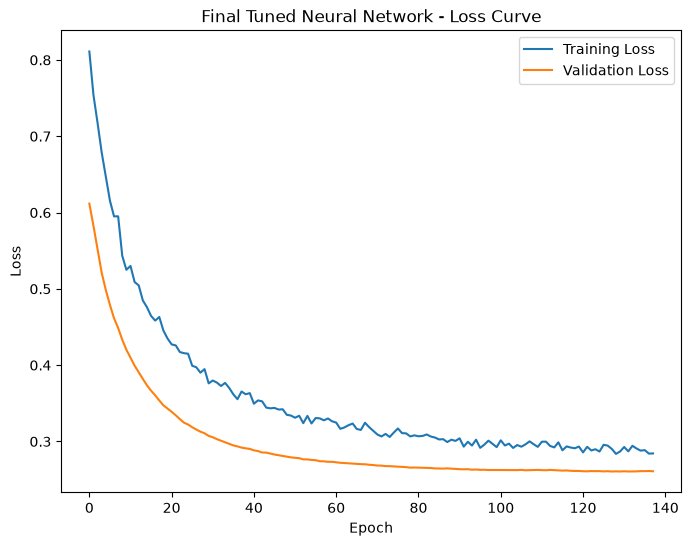

In [49]:
plt.figure(figsize=(8, 6))
plt.plot(final_history.history["loss"], label="Training Loss")
plt.plot(final_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Tuned Neural Network - Loss Curve")
plt.legend()
plt.show()

### Loss Curve Interpretation

Both the Training Loss and Validation Loss decreased steadily during training.

The Validation Loss remained stable and did not begin increasing, which indicates that the final tuned model controlled overfitting effectively.

The Validation Loss was slightly lower than the Training Loss for most epochs. This is expected because Dropout is active during training but disabled during validation.

Overall, the loss curves show stable learning and good generalization.

### Final Tuned Model Accuracy Curve

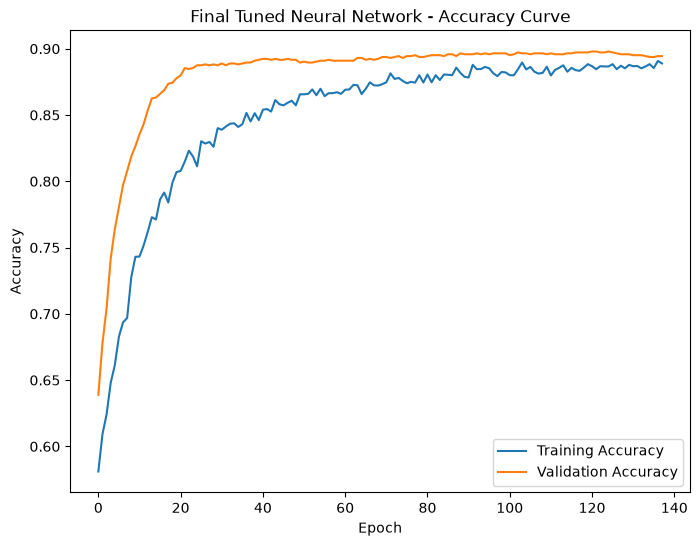

In [50]:
plt.figure(figsize=(8, 6))

plt.plot(final_history.history["accuracy"], label="Training Accuracy")
plt.plot(final_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Tuned Neural Network - Accuracy Curve")
plt.legend()
plt.show()

### Accuracy Curve Interpretation

Both Training Accuracy and Validation Accuracy increased steadily during training.

Validation Accuracy reached approximately **0.89–0.90** and remained stable during the later epochs.

The gap between Training Accuracy and Validation Accuracy remained small, indicating that the model generalized well without severe overfitting.

Validation Accuracy was slightly higher than Training Accuracy for most epochs, which can occur because Dropout is active during training but disabled during validation.

Overall, the Accuracy curves indicate stable and effective learning.

### Final Tuned Model Recall Curve

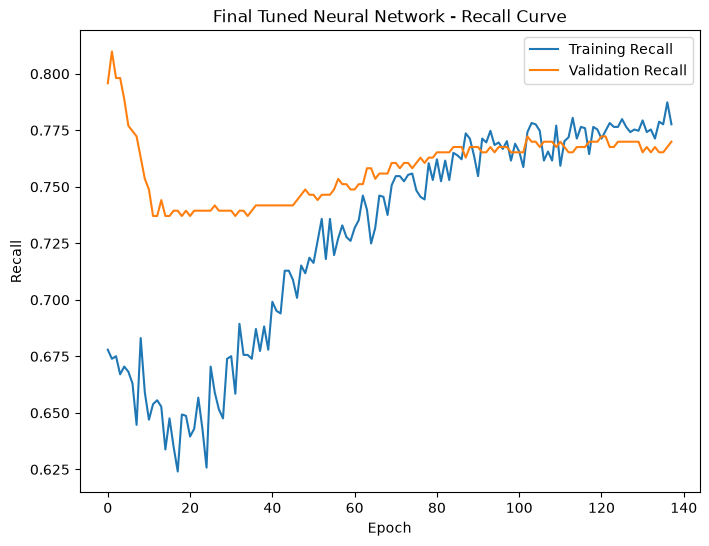

In [51]:
plt.figure(figsize=(8, 6))

plt.plot(final_history.history["recall"], label="Training Recall")
plt.plot(final_history.history["val_recall"], label="Validation Recall")

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Final Tuned Neural Network - Recall Curve")
plt.legend()
plt.show()

### Recall Curve Interpretation

The Training Recall improved gradually during training and reached approximately **0.78**.

Validation Recall initially fluctuated, then became more stable and gradually improved to approximately **0.77**.

Toward the end of training, the Training Recall and Validation Recall became very close, which indicates that the model generalized well without a large gap between training and validation performance.

Overall, the Recall curve shows that the tuned Neural Network learned to identify positive Heart Disease cases more effectively while maintaining stable validation performance.

## Step 5 — Sprint Review & Retrospective

### Sprint Review

During this sprint, the Neural Network was built, regularized, tuned, and evaluated.

The main tuning experiments focused on:

- Learning Rate
- Network Size
- Dropout Rate
- Batch Size

The final selected configuration was:

| Hyperparameter | Final Value |
|---|---:|
| Learning Rate | 0.0001 |
| Network Size | 32 → 16 |
| Dropout Rate | 0.5 |
| Batch Size | 32 |

The final tuned Neural Network achieved:

| Metric | Result |
|---|---:|
| Test Loss | 0.2397 |
| Test Accuracy | 0.9122 |
| Test Recall | 0.8309 |

The tuned Neural Network achieved the highest Accuracy among the evaluated models.

However, the Random Forest baseline still achieved a slightly higher Recall of 0.85, which remains important because this project prioritizes detecting positive Heart Disease cases.

### Sprint Retrospective

#### What Went Well

The Neural Network improved significantly after systematic tuning.

Using EarlyStopping and ModelCheckpoint made the training process more efficient and helped preserve the best model.

The tuning experiments were performed one variable at a time, which made it easier to understand the effect of each hyperparameter.

#### What Could Be Improved

Some experiments required many epochs before EarlyStopping stopped the training.

The Neural Network still did not exceed the Random Forest baseline in Recall.

#### Concrete Change for the Next Sprint

In the next sprint, model improvements will focus more directly on Recall and reducing False Negatives while maintaining good overall performance.